## Evaluation Demo

In this workbook, you can reproduce the figures which we include in our paper. In particular, we demonstrate the following tests:

1. Input sequence length evaluation              ✅
2. Triplet vs. quadruplet training loss function ✅ -- but the results of this comparison aren't great (both are amazing) -- need to find worse scenarios
3. Fingerprint's temporal consistency            ✅ -- but we need to refactor everything to make it look more pretty
4. Multi-RX fingerprinting                       ⏳ -- practically the same thing as (2), but: multi-RX weight-based evaluation
5. Dataset confusion matrices                    ⏳ -- same as (4), but for both closed set and open set, and multi-RX weight-based

Requirements:

* Software: Matlab (tested with R2024a)
* Datasets: `DatasetAPI.DATASET_V2` and `DatasetAPI.DATASET_V4`

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

2024-11-05 20:56:07.247604: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 20:56:07.247666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 20:56:07.248637: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 20:56:07.257382: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-05 20:56:07.939574: W tensorflow/compiler/tf2

### Let's pick a dataset

For this project, we captured two separate datasets in the Orbit testbed facility. Both serve the same purpose, but have a few differentiations:

* `DatasetAPI.DATASET_V2`: focuses on long-term signal capture (>24hrs), but compromises on the number of emitting devices (9-10 throughout epochs). Signal is captured from 4 receivers.
* `DatasetAPI.DATASET_V4`: focuses on shorter-term signal capture (~4hrs), but provides a larger number of available emitters (20 throughout epochs). Signal is captured from 3 receivers.

Select which one you'd like to use for this experiment, and all the configurations will be adjusted accordingly ()

In [2]:
# DATASET_NAME = DatasetAPI.DATASET_V2 # also called Day 1
# DATASET_NAME = DatasetAPI.DATASET_V4 # also called Day 2
DATASET_NAME = DatasetAPI.DATASET_V2V4

### Let's configure the system

In the cell below, we configure the settings for the system. Here's high-level overview of what these configs mean:

* `ROOT_DIRECTORY`: this is the root directory, where we expect to find all the datasets
* `MATLAB_SRC_DIRECTORY`: a directory in this project, where we can access the Matlab code for running data augmentation scripts
* `MATLAB_SESSION_ID`: a live Matlab session name, which we'll connect to for running augmentation scripts
* `DATA_CONFIG`: a dict with configurations for how to work with the dataset
* `AUG_CONFIG`: a dict with configurations for how to augment the dataset
* `MODEL_CONFIG`: a dict with configurations for how we'll train the fingerprint extractor model
* `RX_NODES`: a list of RX node names, which is different for different datasets

In [3]:
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_worklow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 2,
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 10]),
    'k_factor_bounds':   matlab.double([0, 10]),
    'awgn':              matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    'loss_type':         'triplet_loss', 'loss_num_neg': 1,
    # 'loss_type':         'quadruplet_loss', 'loss_num_neg': 2,
    'npair_type':        'samedev',
    'alpha':             1.1,
    'patience':          10,
    'fp_len':            512,
    'row':               80,
    'enable_ind':        True
}

# The only differences between the two datasets are the numbers of receivers from which
# we were able to capture the signal
if DATASET_NAME in [DatasetAPI.DATASET_V4, DatasetAPI.DATASET_V2V4]: RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_4]
else: RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]

### Next, we'll initialize the main APIs:

* `ExtractorAPI`: functions that are useful for working with the fingerprint extractor models (training, loading, etc)
* `DatasetAPI`: functions that are useful for working with the dataset (reading, filtration, transformation, etc)
* `FingerprintingAPI`: functions that are useful for running the fingerprinting tasks (vector similarity search, etc)
* `EvaluationAPI`: service functions for running experiments displayed in our paper, primarily invoked from this notebook

In [4]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
eval_api = EvaluationAPI(rx_ids = RX_NODES, data_config=DATA_CONFIG, aug_config=AUG_CONFIG, model_config=MODEL_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

### Plot the model layers and testbed topology map

This step is optional, but if you'd like to explore the composition of the fingerprint extractor model, run the next cell. You will find two types of printout: a figure (using `visualkeras`) and a standard model summary printout in the terminal.

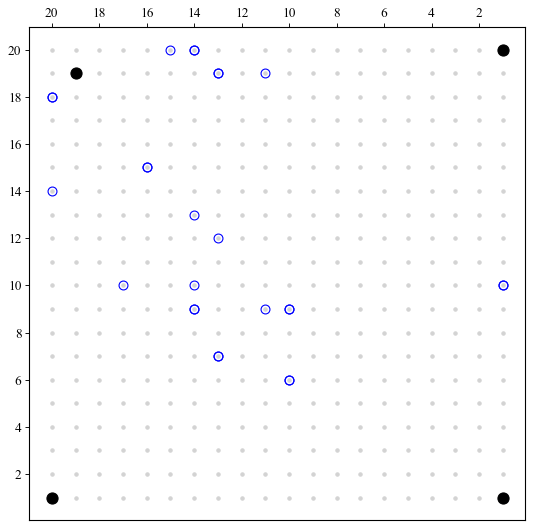

In [5]:
utils.apply_ieee_style()
eval_api.render_orbit_grid(
    tx_node_ids_1 = DatasetAPI.DATASET_V4_TX_MAX_DEVICES, 
    tx_node_ids_2 = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS, 
    rx_node_ids = [1, 20, 381, 379], 
    tx_node_id_curr = -1)

### Let's prepare the models

Here, you have two options:

* Option A: load pre-trained models (they would be stored in the `my_models` dir in the pre-processed dataset folder)
* Option B: train separate models for each RX from scratch (obviously, takes much longer to complete)

In [5]:
def get_extractor_models(fp_api, ndays, augment_multiplier, enable_training, plot_history, show_summary):
    # fp_api.train_models(apply_noise=False)
    if enable_training:
        models, histories = fp_api.train_models_mobrffi_v2v4(apply_noise=False, ndays=ndays, augment=True, augment_cfo=False, augment_multiplier=augment_multiplier)
        if plot_history and len(histories.values()) > 0:
            history = histories[RX_NODES[0]]
            plt.figure(figsize=(8, 6))
            plt.plot(history.history['loss'], label='Training Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title('Model Loss During Training')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.show()
        if show_summary and len(models.values()) > 0:
            models.values()[0].summary()

    else: 
        models = fp_api.load_models()

    return models

In [7]:
fp_api.train_models(apply_noise=False)

2024-11-05 20:29:40.519270: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79060 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-11-05 20:29:40.520692: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79060 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-11-05 20:29:40.521979: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79060 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Epoch 1/1000


2024-11-05 20:29:42.520680: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-11-05 20:29:44.335514: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fd8a80cc7b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-05 20:29:44.335553: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-05 20:29:44.335559: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-05 20:29:44.335564: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-11-05 20:29:44.340258: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1730856584.434418 2139226 device_compi

145/145 [==============================] - 8s 27ms/step - loss: 0.1780 - val_loss: 0.0435 - lr: 0.0010
Epoch 2/1000
145/145 [==============================] - 3s 19ms/step - loss: 0.0353 - val_loss: 0.0159 - lr: 0.0010
Epoch 3/1000
145/145 [==============================] - 3s 19ms/step - loss: 0.0166 - val_loss: 0.0090 - lr: 0.0010
Epoch 4/1000
145/145 [==============================] - 3s 19ms/step - loss: 0.0092 - val_loss: 0.0075 - lr: 0.0010
Epoch 5/1000
145/145 [==============================] - 3s 19ms/step - loss: 0.0063 - val_loss: 0.0037 - lr: 0.0010
Epoch 6/1000
145/145 [==============================] - 3s 20ms/step - loss: 0.0047 - val_loss: 0.0040 - lr: 0.0010
Epoch 7/1000
145/145 [==============================] - 3s 19ms/step - loss: 0.0031 - val_loss: 0.0024 - lr: 0.0010
Epoch 8/1000
145/145 [==============================] - 3s 19ms/step - loss: 0.0024 - val_loss: 0.0018 - lr: 0.0010
Epoch 9/1000
145/145 [==============================] - 3s 18ms/step - loss: 0.0018 -

({'node1-1': <keras.src.engine.functional.Functional at 0x7fddacb458a0>,
  'node1-20': <keras.src.engine.functional.Functional at 0x7fddad01e7a0>,
  'node20-1': <keras.src.engine.functional.Functional at 0x7fdbcd03d960>,
  'node19-19': <keras.src.engine.functional.Functional at 0x7fdbbdf93850>},
 {'node1-1': <keras.src.callbacks.History at 0x7fdc1c0abf10>,
  'node1-20': <keras.src.callbacks.History at 0x7fddacd218d0>,
  'node20-1': <keras.src.callbacks.History at 0x7fdbcd047340>,
  'node19-19': <keras.src.callbacks.History at 0x7fdbbdfcabf0>})

### Experiment 1. The impact of the preamble

To train the fingerprint extractor, we are using preambles of 802.11 frames. This raises a few questions:

* Why preambles? Why can't we use other sections of an OFDM frame
* Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?

To answer these questions, we perform the following experiments:

1. We train the model on 802.11 preambles, and test enrollment/identification on sections of frames with a shifting start index;
2. Next, we also try training the model on non-preamble section of a frame (index 400-800), and repeat the same testing plan.
3. Importantly, since we're performing simple A/B tests, we only evaluate performance for a closed-set problem (via KNN classification), for a single receiver, and for only two epochs.

These results can let us answer the questions above:

* **Why preambles? Why can't we use other sections of an OFDM frame** -- because this is the only section of a frame that doesn't contain "random" data. We can see this by reviewing the 2nd figure. Since the model was trained on non-preamble samples, the max accuracy the model ever achieves is 65%, which is not acceptable.

* **Even if we use preambles, shouldn't the model focus only on hardware imperfections? Why can't we use other sections to enroll/identify devices?** -- The model doesn't extract only hardware imperfections. The fingerprints incorporate data-specific features as well, which makes it essential to use the exact same preamble section for training & testing.

In [ ]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')


eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=0, offset_range=np.arange(0, 610, 1), use_pretrained=True, 
                                  fig_name="Preamble offset evaluation: preamble-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig1.eps'),
                                  enroll_device_idx = enroll_device_idx,
                                  identify_device_idx = identify_device_idx)
eval_api.evaluate_preamble_offset(rx_id=DatasetAPI.RX_1, 
                                  frame_start_train=400, offset_range=np.arange(0, 610, 1), use_pretrained=False, 
                                  fig_name="Preamble offset evaluation: random data-based training",
                                  fig_path=os.path.join(ROOT_DIRECTORY, 'fig2.eps'),
                                  enroll_device_idx = enroll_device_idx,
                                  identify_device_idx = identify_device_idx)

print('Done')

### 2. Experiment #2: Triplet vs. quadruplet training loss function

Every bit matters. Let's try adopting a quadruplet loss function and explore model performance on an identical dataset & settings.

Note: currently, the test is being performed under open-set conditions. You can override this by defining identical device ID sets in this function, and run closed-set test.

In [ ]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')

eval_api.evaluate_loss_function(rx_id = DatasetAPI.RX_1, fig_path = ROOT_DIRECTORY, enroll_device_idx=enroll_device_idx, identify_device_idx=identify_device_idx)

### Experiment 3. Fingerprint's temporal consistency

Generating eval finerprints for node1-1...
..........................................................................................................................................................................Generating eval finerprints for node1-20...
..........................................................................................................................................................................Generating eval finerprints for node20-1...
..........................................................................................................................................................................Generating eval finerprints for node19-19...
..........................................................................................................................................................................

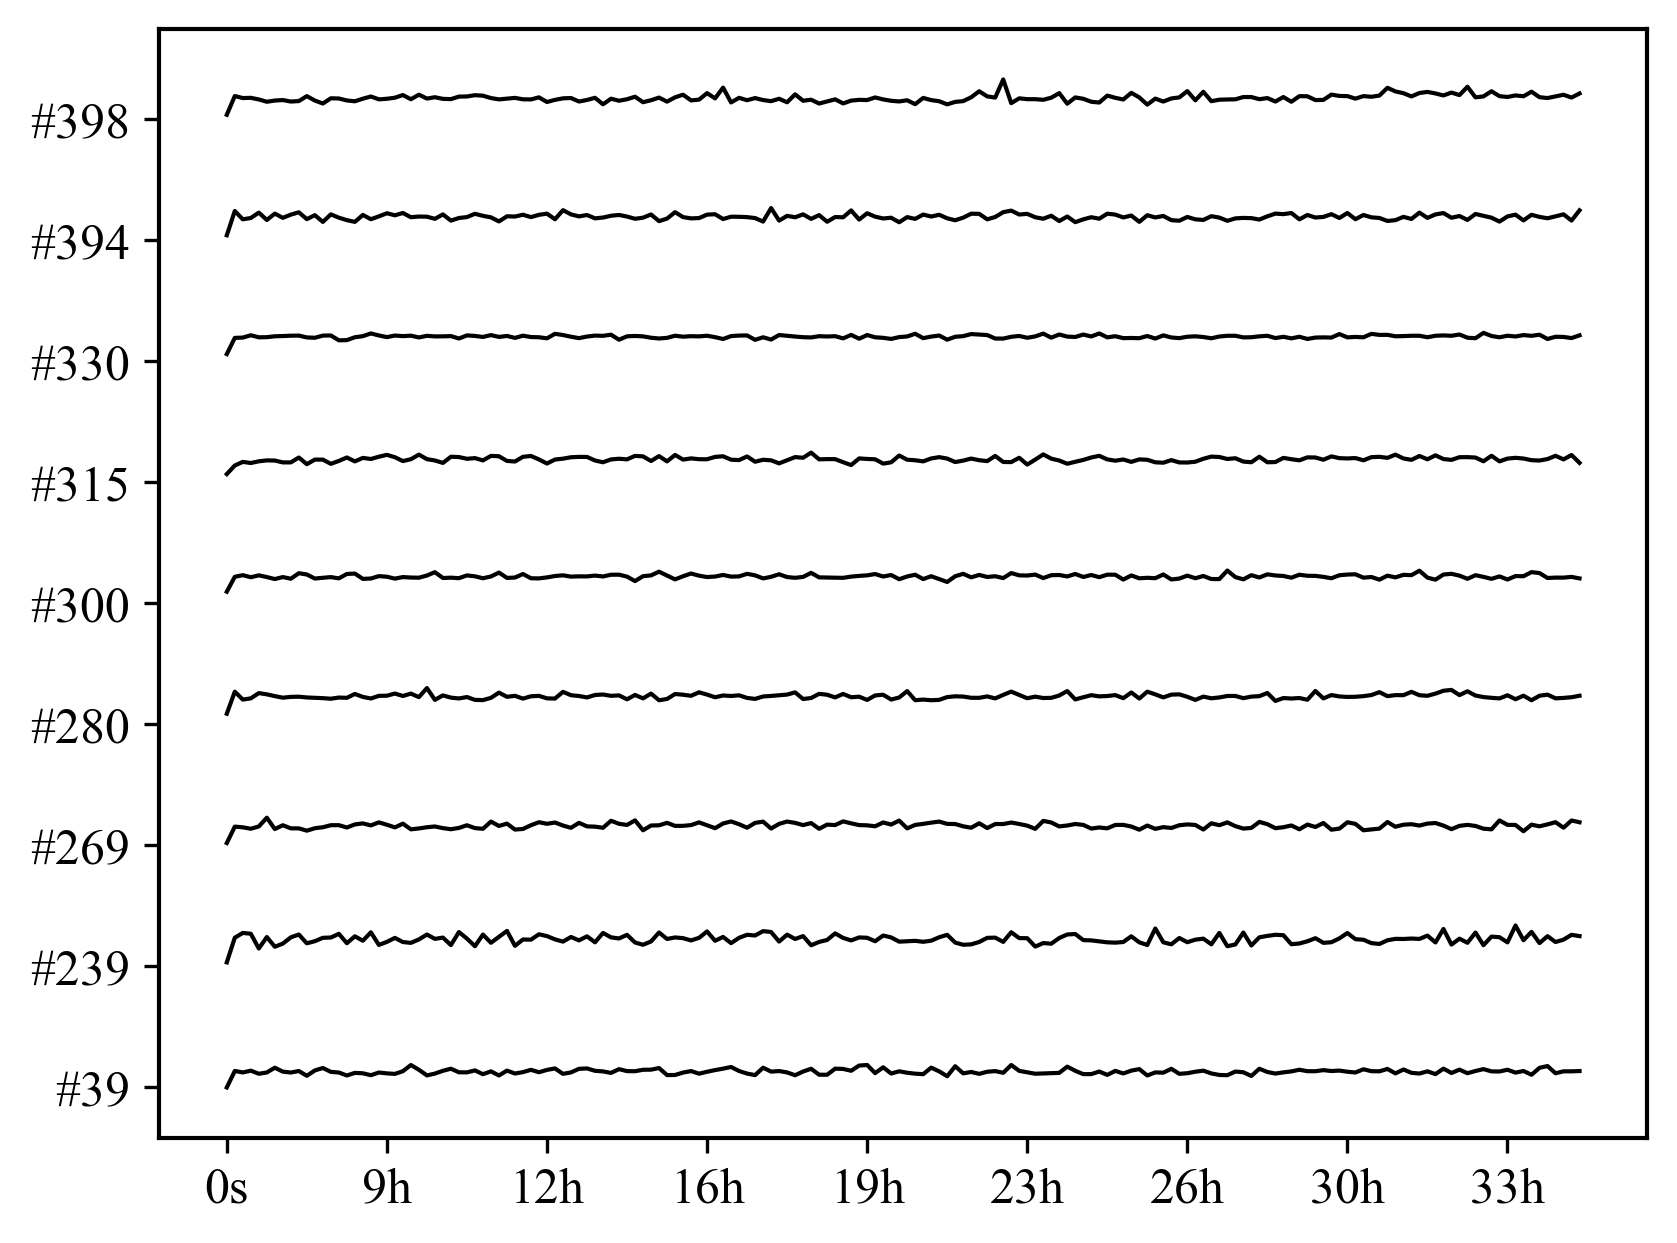

Re-identification threshold: 0.44297746720049347


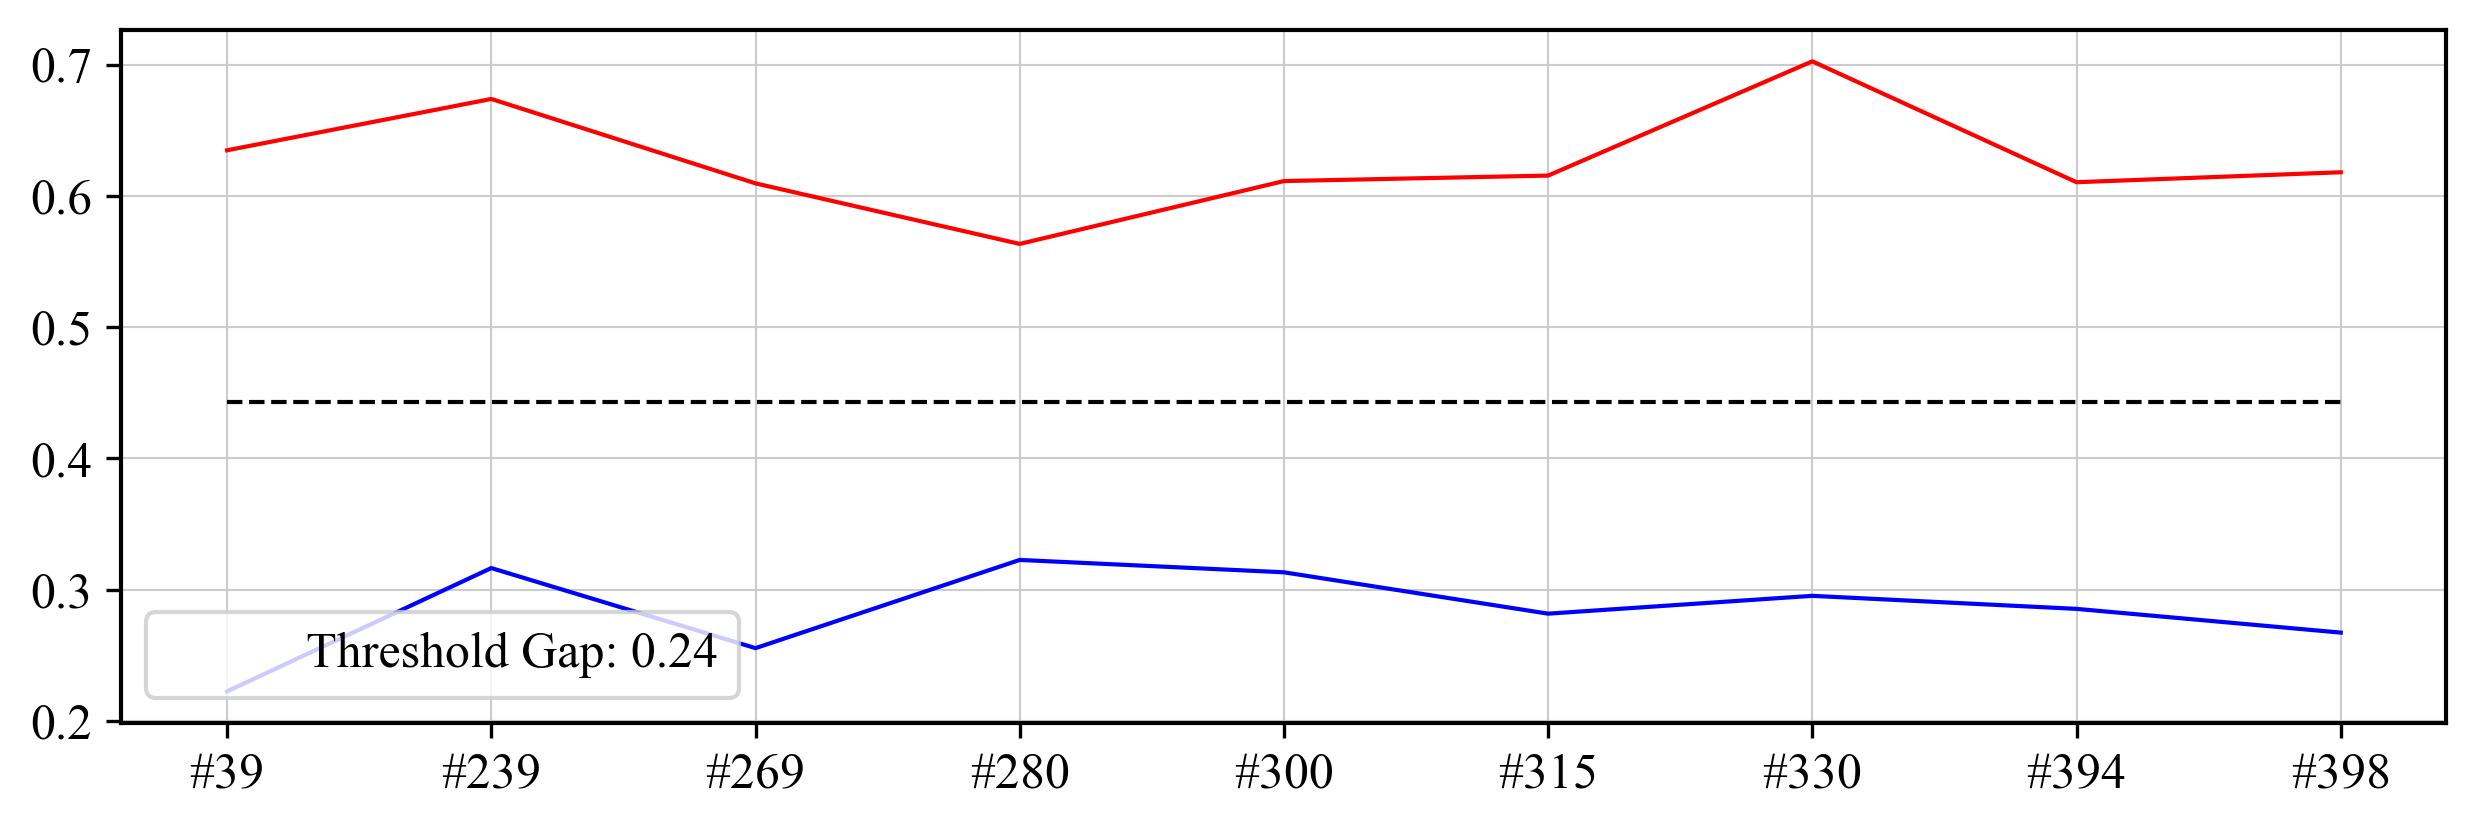

In [11]:
if DATASET_NAME == DatasetAPI.DATASET_V2:
    node_ids_epoch_override=DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
    epochs_override=DatasetAPI.DATASET_V2_EPOCHS_MAX_DEVICES
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    node_ids_epoch_override=DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
    epochs_override=DatasetAPI.DATASET_V4_EPOCHS_MAX_DEVICES
else:
    print(f'No configs for {DATASET_NAME}')

# models, _ = fp_api.train_models(apply_noise=False)
models = fp_api.load_models()

fp_distances = eval_api.evaluate_temporal_stability(
    models, RX_NODES, 
    node_ids_epoch=node_ids_epoch_override, 
    epochs_override=epochs_override, 
    fig_path=ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=True, 
    rank_dist_fig_file = False)

### Experiment 4. Multi-RX fingerprinting

The task here is slightly more interesting. While previously we evaluated the process of training the model, as well as whether the model can extract time-insensitive features -- now we can consider whether it's possible to improve the system performance by combining (aka fusing) fingerprints from multiple receivers that "hear" our signal simultaneously. 

This requires a slightly different process. Previous model tests could be performed while using a simple KNN-based evaluator. This step requires building out a custom evaluator, which is going to let us combine KNN distances with our custom weight factor -- RSSI (normalized between 0 and 1 on a -100 to 0 dB scale). 

Here's how this evaluation will work: 

1. We will build an evaluator which performs the evaluation process using a custom list of receivers. 
2. We will then run this evaluator for the following combinations:
    * RX 1
    * RX 2
    * RX 3
    * RX 4
    * RX 1, 2
    * RX 1, 2, 3
    * rX 1, 2, 3, 4
3. We will compare their performance on both closed-set and open-set scenarios, and produce the same accuracy metrics as before
4. Optionally, we will let the user render a rank 1-2 plot across all devices

In [ ]:
from dataset_preparation import awgn

if DATASET_NAME == DatasetAPI.DATASET_V2:
    enroll_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V2_TX_MAX_EPOCHS
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    enroll_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS[0:5]
    identify_device_idx = DatasetAPI.DATASET_V4_TX_MAX_EPOCHS
else:
    print(f'No configs for {DATASET_NAME}')

print(enroll_device_idx)
print(identify_device_idx)

aug_on = False
apply_noise = False

epoch_idx_enroll = 0
epoch_idx_identify = 1

frame_count_enroll = frame_count_identify = 100

models = {}
data_epochs_1 = {}
labels_epochs_1 = {}
data_epochs_2 = {}
labels_epochs_2 = {}
rssis_epoch_2 = {}

for rx_id in RX_NODES:
    print(f"Load the training dataset for {rx_id}")
    dataset_train_path, dataset_epoch_paths, model_path, node_ids_train, _, samp_rate = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], rx_id, None)
    if aug_on: data, label, rssi = dataset_api.load_augmented_dataset(dataset_train_path, samp_rate, AUG_CONFIG, shuffle=True)
    else: data, label, rssi = dataset_api.load_raw_dataset(dataset_train_path, shuffle=True)
    data, label, rssi = dataset_api.filter_dataset(data, label, rssi, node_ids_train, np.arange(0, DATA_CONFIG['frame_count_train']))
    if apply_noise: data = awgn(data, np.arange(AUG_CONFIG['awgn'][0][0], AUG_CONFIG['awgn'][0][1]))
    data_train = data[:, 0:0+DATA_CONFIG['samples_count']]

    # feature_extractor, _ = extractor_api.train(data_train, label, node_ids_train, MODEL_CONFIG, save_path=None)
    models[rx_id] = extractor_api.load(os.path.join(model_path, f"extractor_{rx_id}.keras"))

    # Load data (two epochs: one to enroll devices, another to identify devices)
    data_enroll, labels_enroll, rssi_enroll = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_enroll], shuffle=True)
    data_identify, labels_identify, rssi_identify = dataset_api.load_raw_dataset(dataset_epoch_paths[epoch_idx_identify], shuffle=True)

    data_enroll, labels_enroll, _ = dataset_api.filter_dataset(data_enroll, labels_enroll, rssi_enroll, dev_range=enroll_device_idx, pkt_range=np.arange(frame_count_enroll))
    data_identify, labels_identify, rssi_identify = dataset_api.filter_dataset(data_identify, labels_identify, rssi_identify, dev_range=identify_device_idx, pkt_range=np.arange(frame_count_identify))

    data_epochs_1[rx_id] = data_enroll[:, 0:DATA_CONFIG['samples_count']]
    data_epochs_2[rx_id] = data_identify[:, 0:DATA_CONFIG['samples_count']]

    labels_epochs_1[rx_id] = labels_enroll
    labels_epochs_2[rx_id] = labels_identify

    rssis_epoch_2[rx_id] = rssi_identify

if DATASET_NAME == DatasetAPI.DATASET_V2:
    epochs = [
        'epoch_2024-07-20_01-15-26',
        'epoch_2024-07-20_01-25-24']
elif DATASET_NAME == DatasetAPI.DATASET_V4:
    epochs = [
        'epoch_2024-08-08_19-19-27',
        'epoch_2024-08-08_19-59-37']
else:
    print(f'No configs for {DATASET_NAME}')

fp_distances_1 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[1:2], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_1.eps')

fp_distances_2 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:2], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_12.eps')

fp_distances_3 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:3], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_123.eps')

fp_distances_4 = eval_api.evaluate_temporal_stability(
    models, RX_NODES[0:4], 
    identify_device_idx, 
    epochs_override=epochs, 
    fig_path = ROOT_DIRECTORY, 
    render_heatmaps=False, 
    render_temp_stability=False, 
    rank_dist_fig_file='fp_rank_1234.eps')

[39, 239, 269, 280, 300]
[39, 239, 269, 280, 300, 315, 330, 394, 398]
Load the training dataset for node1-1
Load the training dataset for node1-20
Load the training dataset for node20-1
Load the training dataset for node19-19


### Experiment 4. Multi-RX Multi-day Closed-Set Fingerprinting

### IMPORTANT: this section requires you to re-load the libraries and settings wtih `DatasetAPI.DatasetV2V4`

Enrolling device 269: (14, 9)
This is a new device. New ID: bb340620-f817-42a0-bae7-f6d8cda342fa
Enrolling device 398: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: cebbbc00-da3c-49e0-b1bc-ce71bd00c246
Enrolling device 280: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: d8fe4fcb-6c88-455e-b2e3-f3ced437106e
Enrolling device 315: (16, 15)
This is a new device. New ID: de00d734-1841-4ab2-a41c-49c227d56a4d
Enrolling device 394: (20, 14)
This is a new device. New ID: 18dd55ba-59dc-449a-93a8-2cc07f53c567
Enrolling device 300: (15, 20)
This is a new device. New ID: dd13e935-5765-49d6-993a-2bb1dfac8d34
Enrolling device 330: (17, 10)
This is a new device. New ID: e9450230-c1e2-47e9-aedf-2e5efa5bbb67
E1. Identifying a device: (14, 9)
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42a0-bae7-f6d8cda342fa
|This is a known device. ID: bb340620-f817-42

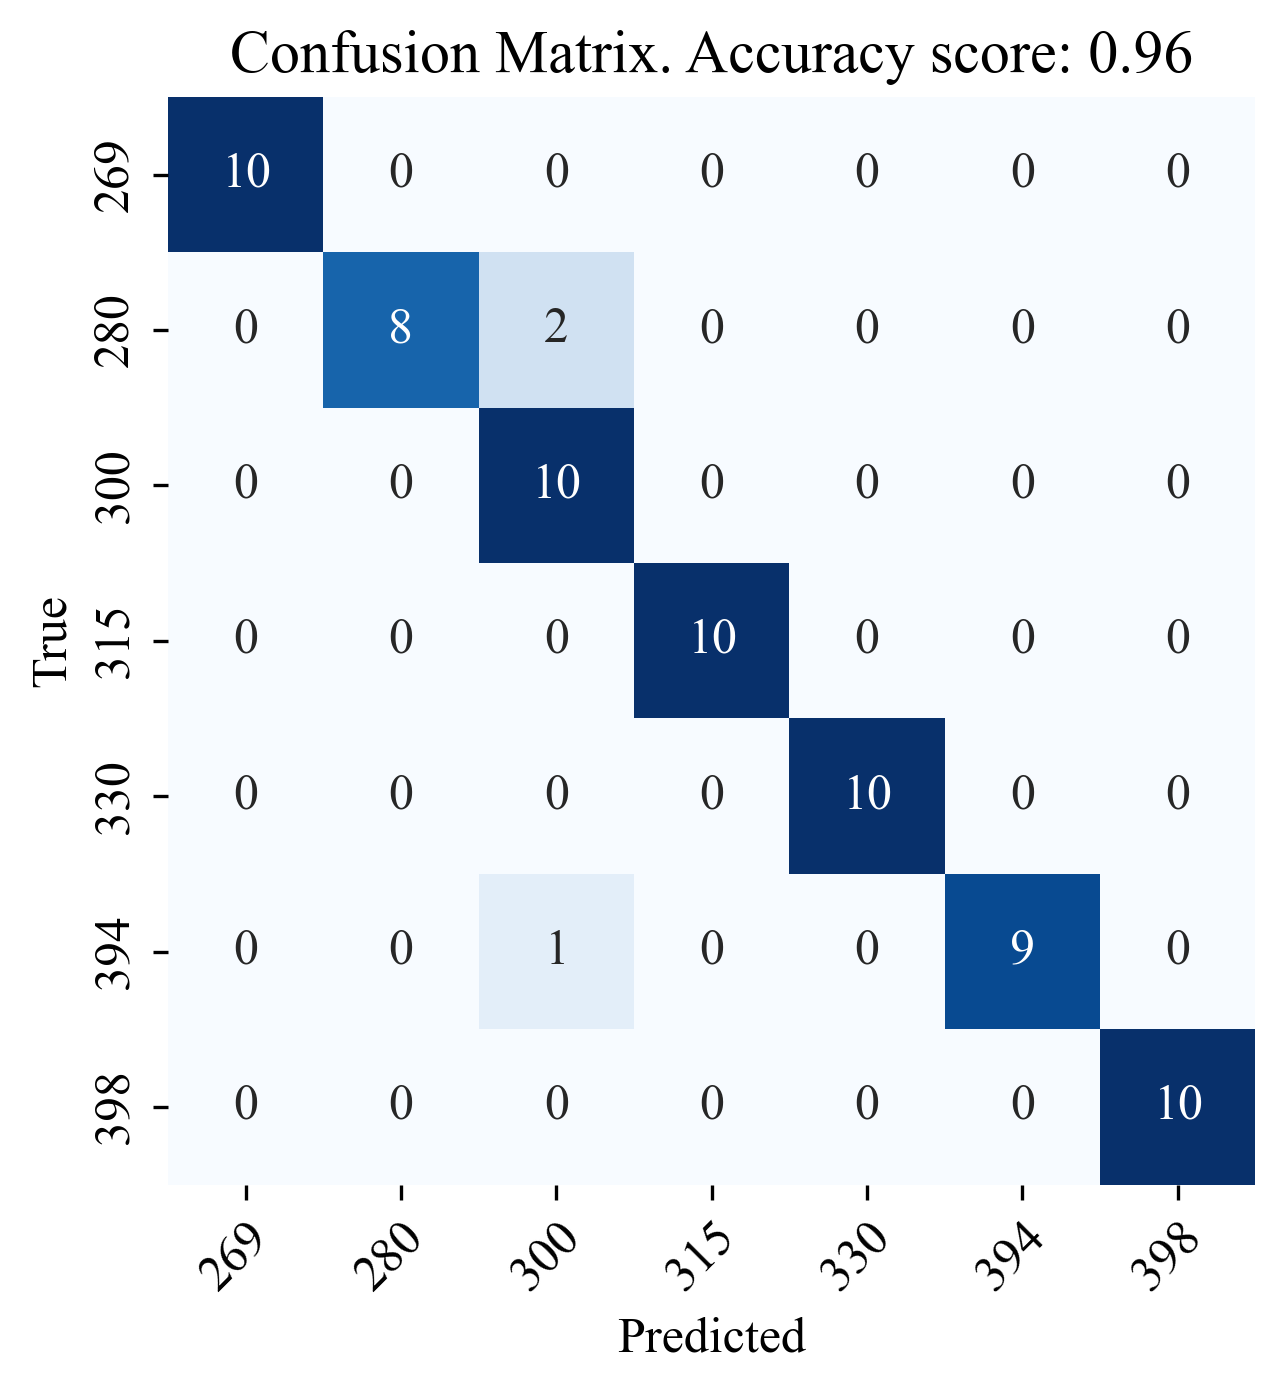

Accuracy score: 0.96
Enrolling device 269: (14, 9)
This is a new device. New ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
Enrolling device 398: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: d76833fa-2811-4efc-9a8e-aa74bc820840
Enrolling device 280: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 0f3e3b67-dbb3-4621-a7e0-48eb38de7186
Enrolling device 315: (16, 15)
This is a new device. New ID: feb51fc9-8166-4bd0-a2ba-29434b9dac31
Enrolling device 394: (20, 14)
This is a new device. New ID: 59c30b0c-f1b1-402b-8f35-2b603fe53def
Enrolling device 300: (15, 20)
This is a new device. New ID: 8e875873-9bdb-44fc-9960-b03e444ffa3f
Enrolling device 330: (17, 10)
This is a new device. New ID: 253adb23-2e1b-4f4f-b288-98bbc7a68dd5
E1. Identifying a device: (14, 9)
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f54-bfe2-acd4ddf1a777
|This is a known device. ID: 2c74ca04-bcdd-4f

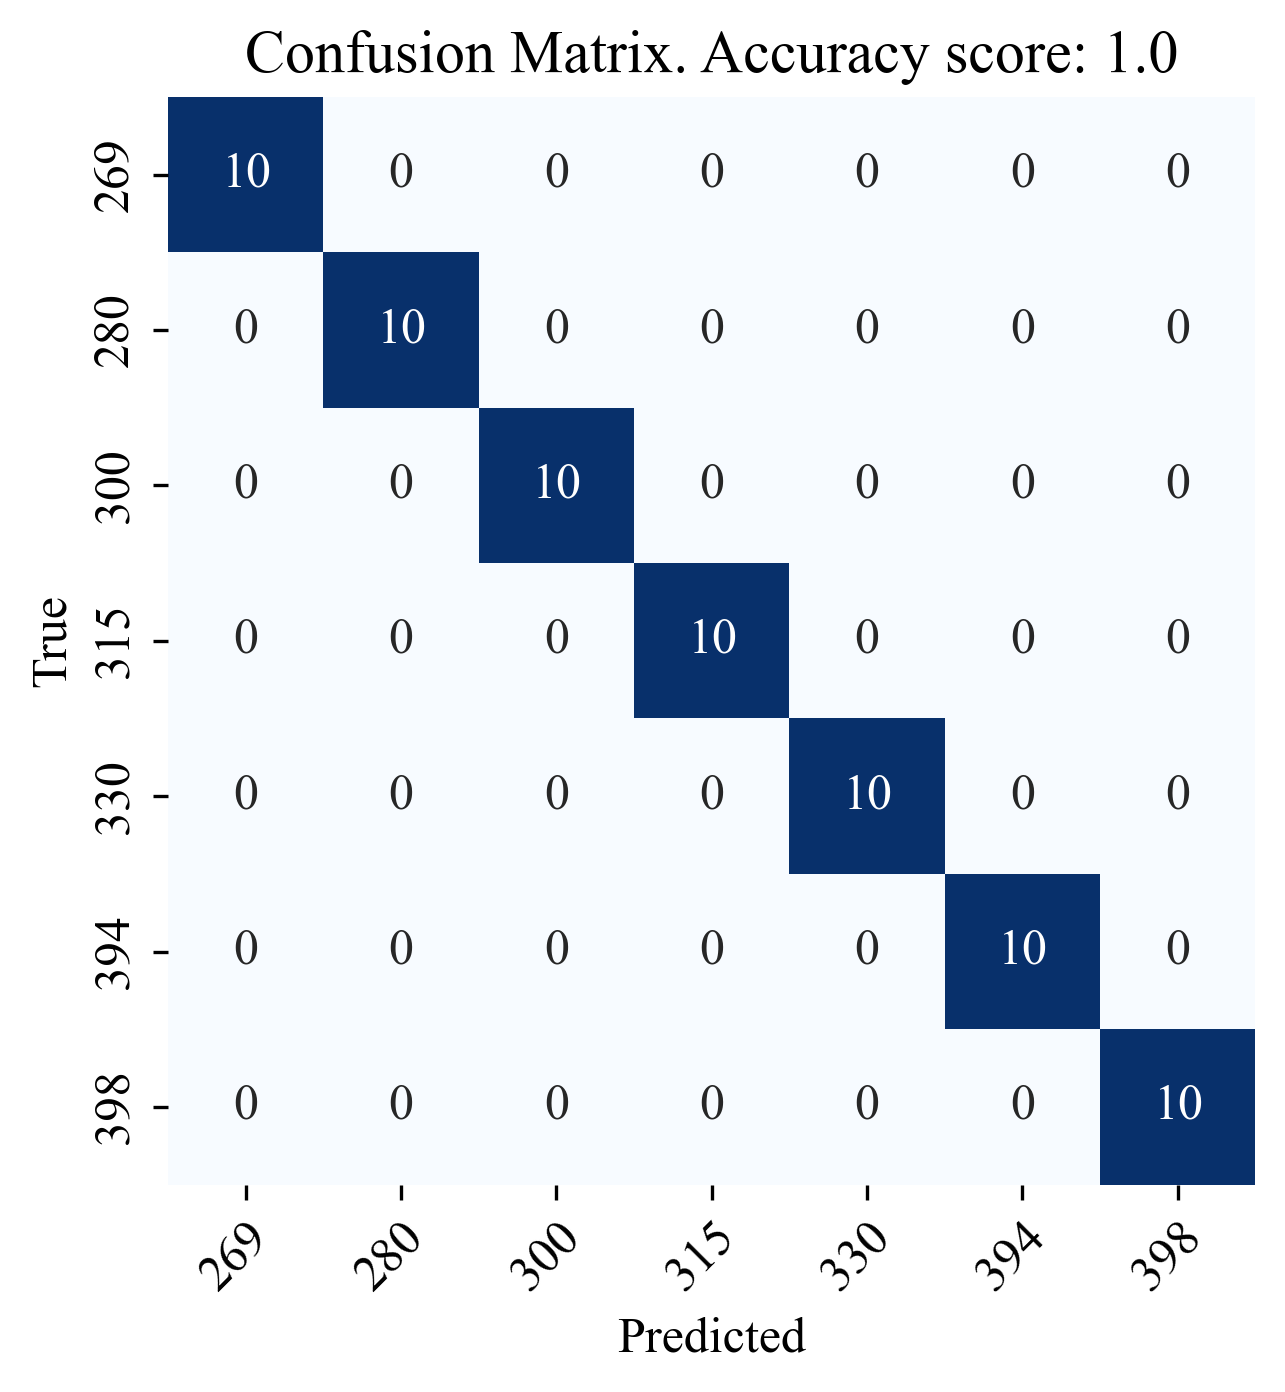

Accuracy score: 1.0
Enrolling device 269: (14, 9)
This is a new device. New ID: b509e6fe-7970-45aa-bdb3-794de0eb654f
Enrolling device 398: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 726a6586-b9ee-4091-b78e-bffd0087f46f
Enrolling device 280: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 36e17249-bc38-42e0-8292-b72272c11b96
Enrolling device 315: (16, 15)
This is a new device. New ID: 6e5ab973-b4fb-4d86-991c-96e09a270ef0
Enrolling device 394: (20, 14)
This is a new device. New ID: bd1a8a84-e240-4e33-b485-1283f7ec96b5
Enrolling device 300: (15, 20)
This is a new device. New ID: 8e9301e0-8be4-428b-a029-c4c94d76b797
Enrolling device 330: (17, 10)
This is a new device. New ID: c5e4cfc9-f865-44fb-8501-2a3678d2b51c
E1. Identifying a device: (14, 9)
|This is a known device. ID: b509e6fe-7970-45aa-bdb3-794de0eb654f
|This is a known device. ID: b509e6fe-7970-45aa-bdb3-794de0eb654f
|

KeyboardInterrupt: 

In [30]:
enable_training = False
training_days = 1
augment_multiplier = 2
ch_ind = True
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
day_identify_i = 3
augment_multiplier=2
disjoint_node_ids = [269, 398, 280, 315, 394, 300, 330]

multi_rx_closed_set_accuracies = []

for rx_nodes_max in range(1, 4):
    rx_nodes = RX_NODES[0:rx_nodes_max]

    data_config = DATA_CONFIG = {'dataset_name': DatasetAPI.DATASET_V2V4, 'frame_count_train': 200, 'frame_count_epoch': 2, 'samples_count': 400}
    model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': ch_ind }
    fp_api = FingerprintingAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
    eval_api = EvaluationAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

    # 1. Let's train (or load) our models
    models = get_extractor_models(fp_api, training_days, augment_multiplier, enable_training=enable_training, plot_history=False, show_summary=False)

    # 2. Let's evaluate closed-set multi-rx performance
    accuracy = eval_api.evaluate_closed_set_multirx(rx_ids = rx_nodes, 
        epoch_idx_enroll = 0, epochs_idx_identify = 1,
        enroll_device_idx = disjoint_node_ids,
        identify_device_idx = disjoint_node_ids,
        frame_count_enroll = 10, frame_count_identify = 10,
        enroll_threshold = 0, identify_threshold = 100,
        fig_path = os.path.join(ROOT_DIRECTORY, 'multirx_closed_set.eps'))

    multi_rx_closed_set_accuracies.append(accuracy)

### Experiment 5. Multi-RX Multi-day Open-set Fingerprinting

Here, our goal is to evaluate ROC curves on MobRFFI dataset with the following parameters:

1. Trained on Day 1
2. Enrolled on Day 1 (disjoint devices)
3. Identified on Day 1, RX1 (same-day curve)
4. Identified on Day 2, RX in [1, 1+2, 1+2+3] (multi-day curves)

Enrolling device: (14, 9)
This is a new device. New ID: c749c864-7f8a-45d4-921d-5611153133e4
Enrolling device: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: c09cb37f-0560-4951-a67a-91d6e863e98b
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: c26efec8-65c2-4ff7-8437-f9cb044036ff
E1. Identifying a device: (14, 9)
|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.
E1. Identifying a device: (20, 18)
|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.|.
E1. Identifying a device: (14, 20)
|.|.|.|.|.|.|.|.|.|.|.|.|.|

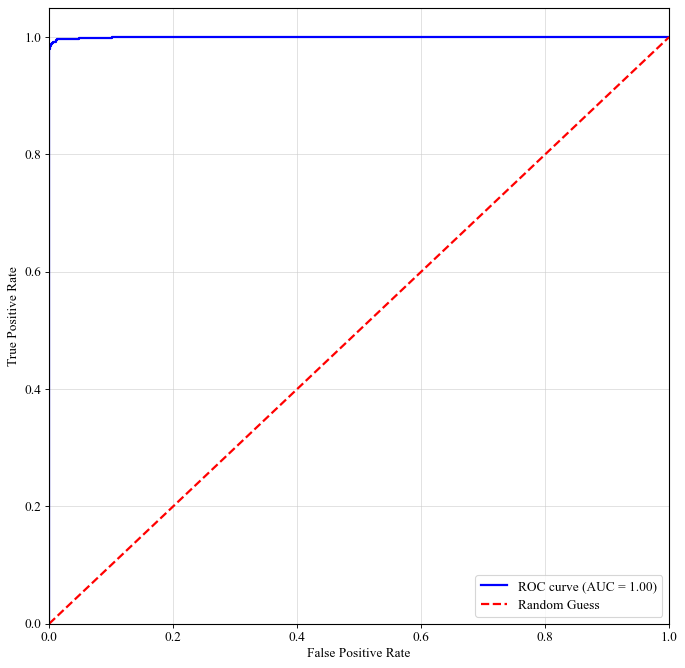

Enrolling device: (14, 9)
This is a new device. New ID: 4bfd47c5-6cc1-4990-9194-e50e2979286d
Enrolling device: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 9ebfb572-7b14-443e-beec-100576186082
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: 7ec66447-ba30-4861-8a33-1adb0295f14a
E1. Identifying a device: (14, 9)
|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..
E1. Identifying a device: (20, 18)
|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|..|.

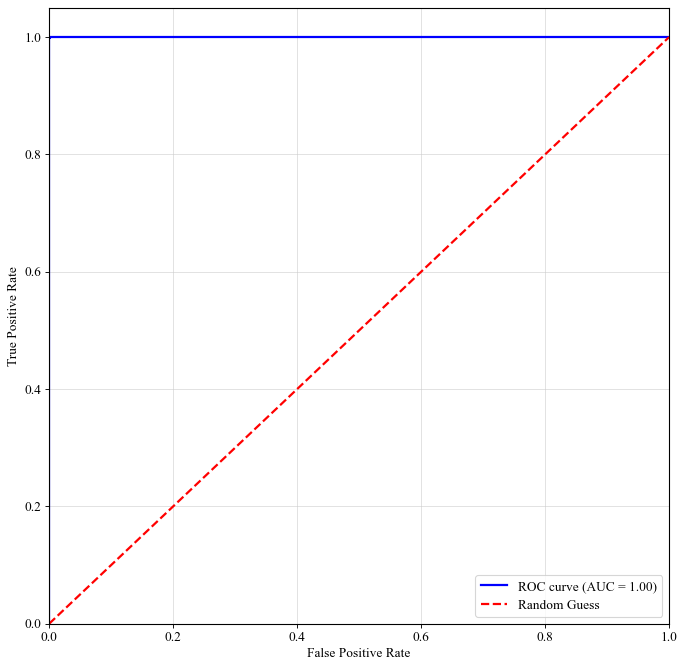

Enrolling device: (14, 9)
This is a new device. New ID: d333a641-671f-43b5-8ec6-ff969a4da096
Enrolling device: (20, 18)


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1
Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a new device. New ID: 9cdddad7-39a7-46da-b8c3-4724d95e235f
Enrolling device: (14, 20)


Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2
Number of requested results 3 is greater than number of elements in index 2, updating n_results = 2


This is a new device. New ID: d4369b11-d735-4138-9e7f-c29c5893df34
E1. Identifying a device: (14, 9)
|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...
E1. Identifying a device: (20, 18)
|...|...|...|...|...|...|...|...|...|...|...|...|...|...|...|..

Traceback (most recent call last):
  File "/home/smazokha2016/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2381962/2619700195.py", line 25, in <module>
    eval_api.evaluate_open_set_multirx(rx_ids=rx_nodes,
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/evaluation_api.py", line 719, in evaluate_open_set_multirx
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/fingerprinting_api.py", line 380, in new_signal
    fps[i, :] = self.extractor_api.run(feature_extractor, np.array([iq]), self.model_config)
  File "/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/extractor_api.py", line 83, in run
    return model.predict(data_freq, verbose=0) #, data_freq
  File "/home/smazokha2016/.local/lib/python3.10/site-packages/keras/src/utils/traceback_utils.py", line 65, in error_handler
    return fn(*args, **kwargs)
  File "/home/smazokha

In [29]:
enable_training = False
training_days = 1
augment_multiplier = 2
ch_ind = True
loss_function = 'triplet_loss'
loss_alpha = 1.1
day_enroll_i = 0
day_identify_i = 3
augment_multiplier=2
disjoint_node_ids_enroll = [269, 398, 280]
disjoint_node_ids_identify = [269, 398, 280, 315, 394, 300, 330]

for rx_nodes_max in range(1, 4):
    rx_nodes = RX_NODES[0:rx_nodes_max]

    data_config = DATA_CONFIG = {'dataset_name': DatasetAPI.DATASET_V2V4, 'frame_count_train': 200, 'frame_count_epoch': 2, 'samples_count': 400}
    model_config = { 'loss_type': loss_function, 'alpha': loss_alpha, 'fp_len': 512, 'row': 80, 'batch_size': 32, 'enable_ind': ch_ind }
    fp_api = FingerprintingAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)
    eval_api = EvaluationAPI(rx_ids = rx_nodes, data_config=data_config, model_config=model_config, aug_config=AUG_CONFIG, root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=AUG_ON)

    # 1. Let's train (or load) our models
    models = get_extractor_models(fp_api, training_days, augment_multiplier, enable_training=enable_training, plot_history=False, show_summary=False)

    # 2. Let's evaluate open-set scenario
    eval_api.evaluate_open_set_multirx(rx_ids=rx_nodes, 
        epoch_idx_enroll = 0, epochs_idx_identify = 1,
        enroll_device_idx = disjoint_node_ids_enroll,
        identify_device_idx = disjoint_node_ids_identify,
        frame_count_enroll = 50, frame_count_identify = 200)

## 6. That's all, folks!

Thank you for exploring our project! If you found this useful, please consider citing our paper. This would mean the world to our team.

![](https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXhkMmpnZTl0ZmYybWd6NzExMWdxNmY1ZmE4Y2h0d3Zsem96ZG9yMSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/lTpme2Po0hkqI/giphy.gif)

```bibtex
@article{mazokha2024rffi,
  title={RFFI for Mobility Intelligence and MAC Address Derandomization},
  author={Mazokha, Stepan and Bao, Fanchen and Sklivanitis, George and Hallstrom, Jason O},
  journal={TBD},
  year={2024},
  publisher={TBD}
}